# Section 3 Extension: Noise Robustness

This notebook tests how Gaussian full-information feedback noise affects Section 3. Each round observes the full matrix sample `A_t = clip(A + sigma * Gaussian, 0, 1)`. The comparison keeps Nash, Hedge, and the official Our-Algo unchanged, and adds `Our-Algo-NoiseAware`, a sigma-adaptive variant that uses a larger update threshold as feedback noise increases.

In [1]:
from importlib import util
from pathlib import Path

from IPython.display import Image, display

MODULE_PATH = Path("section3_noise_robustness.py")
if not MODULE_PATH.exists():
    MODULE_PATH = Path("Extensions/Extension_Noise_Robustness_Full_info_feedback/section3_noise_robustness.py")
MODULE_PATH = MODULE_PATH.resolve()

spec = util.spec_from_file_location("section3_noise_robustness_local", MODULE_PATH)
section3_noise_robustness = util.module_from_spec(spec)
assert spec.loader is not None
spec.loader.exec_module(section3_noise_robustness)

run_and_plot = section3_noise_robustness.run_and_plot
run_convergence_and_plot = section3_noise_robustness.run_convergence_and_plot
plot_section3_noiseaware_improvement = section3_noise_robustness.plot_section3_noiseaware_improvement
print_summary = section3_noise_robustness.print_summary

print("Loaded:", MODULE_PATH)
print("Algorithms:", ", ".join(section3_noise_robustness.ALGORITHM_ORDER))
assert "Our-Algo-NoiseAware" in section3_noise_robustness.ALGORITHM_ORDER


Loaded: D:\Users\Mateo\Personal\_Seminar_RL\Zero-Sum-MatrixGames\Extensions\Extension_Noise_Robustness_Full_info_feedback\section3_noise_robustness.py
Algorithms: Nash, Hedge, Our-Algo, Our-Algo-NoiseAware


## Run Experiment

Use `quick` for a fast check. Use `medium` or `paper-lite` for report-quality runs.

In [2]:
preset = "medium"  # options: "quick", "medium", "paper-lite"
seed = 7

bundle, regret_path, payoff_path = run_and_plot(preset, seed=seed)
metadata = bundle["metadata"]
results = bundle["results"]

for n, algorithm_results in results.items():
    assert "Our-Algo-NoiseAware" in algorithm_results, f"Noise-aware results missing for n={n}"

metadata



-- n=10 -------------------------------------------------------
  sigma=0.00  Nash: R=    0.01, P=0.0492  Hedge: R=    3.81, P=0.0490  Our-Algo: R=    3.92, P=0.0491  Our-Algo-NoiseAware: R=    3.92, P=0.0491  
  sigma=0.10  Nash: R=    5.60, P=0.0490  Hedge: R=    4.20, P=0.0490  Our-Algo: R=    4.20, P=0.0491  Our-Algo-NoiseAware: R=    4.13, P=0.0491  
  sigma=0.20  Nash: R=   10.45, P=0.0488  Hedge: R=    5.89, P=0.0490  Our-Algo: R=    4.63, P=0.0491  Our-Algo-NoiseAware: R=    4.62, P=0.0491  
  sigma=0.30  Nash: R=   35.56, P=0.0480  Hedge: R=    8.96, P=0.0489  Our-Algo: R=    5.96, P=0.0491  Our-Algo-NoiseAware: R=    5.90, P=0.0491  

-- n=20 -------------------------------------------------------
  sigma=0.00  Nash: R=    0.00, P=0.0246  Hedge: R=    2.48, P=0.0245  Our-Algo: R=    4.17, P=0.0246  Our-Algo-NoiseAware: R=    4.17, P=0.0246  
  sigma=0.10  Nash: R=    3.29, P=0.0245  Hedge: R=    2.99, P=0.0245  Our-Algo: R=    4.22, P=0.0246  Our-Algo-NoiseAware: R=    4.13,

{'preset': 'medium',
 'sigma_values': [0.0, 0.1, 0.2, 0.3],
 'n_runs': 8,
 'horizon': 30000}

## Generated Plots

## Relative improvement at high noise

The regret and payoff curves overlap because the original and noise-aware algorithms are close on the plot scale. The bar chart below isolates the comparison at `sigma = 0.3` and shows the percentage regret reduction of `Our-Algo-NoiseAware` relative to `Our-Algo` for each matrix size.

Figure saved -> D:\Users\Mateo\Personal\_Seminar_RL\Zero-Sum-MatrixGames\Extensions\Extension_Noise_Robustness_Full_info_feedback\plots\section3_noiseaware_improvement_medium_sigma0p3.png


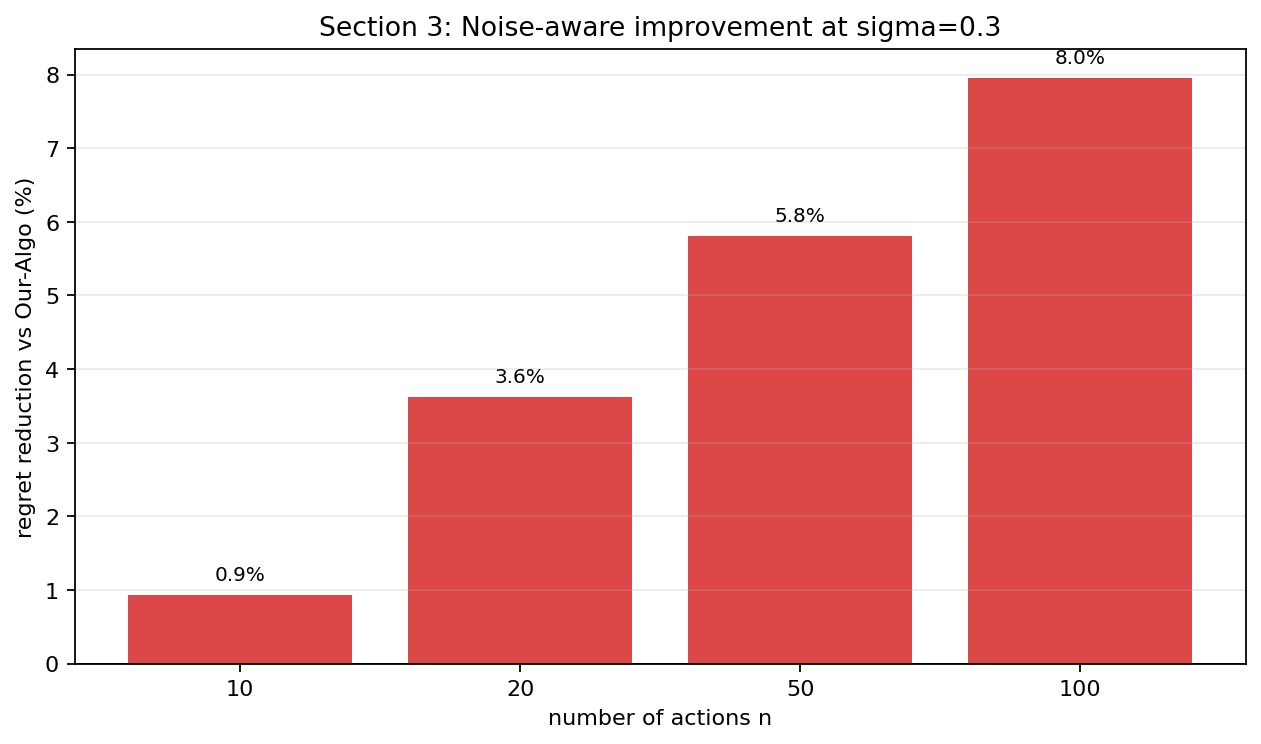

In [3]:
improvement_path = MODULE_PATH.parent / "plots" / f"section3_noiseaware_improvement_{preset}_sigma0p3.png"
plot_section3_noiseaware_improvement(
    results,
    metadata["sigma_values"],
    improvement_path,
    sigma=0.3,
)
display(Image(filename=str(improvement_path)))


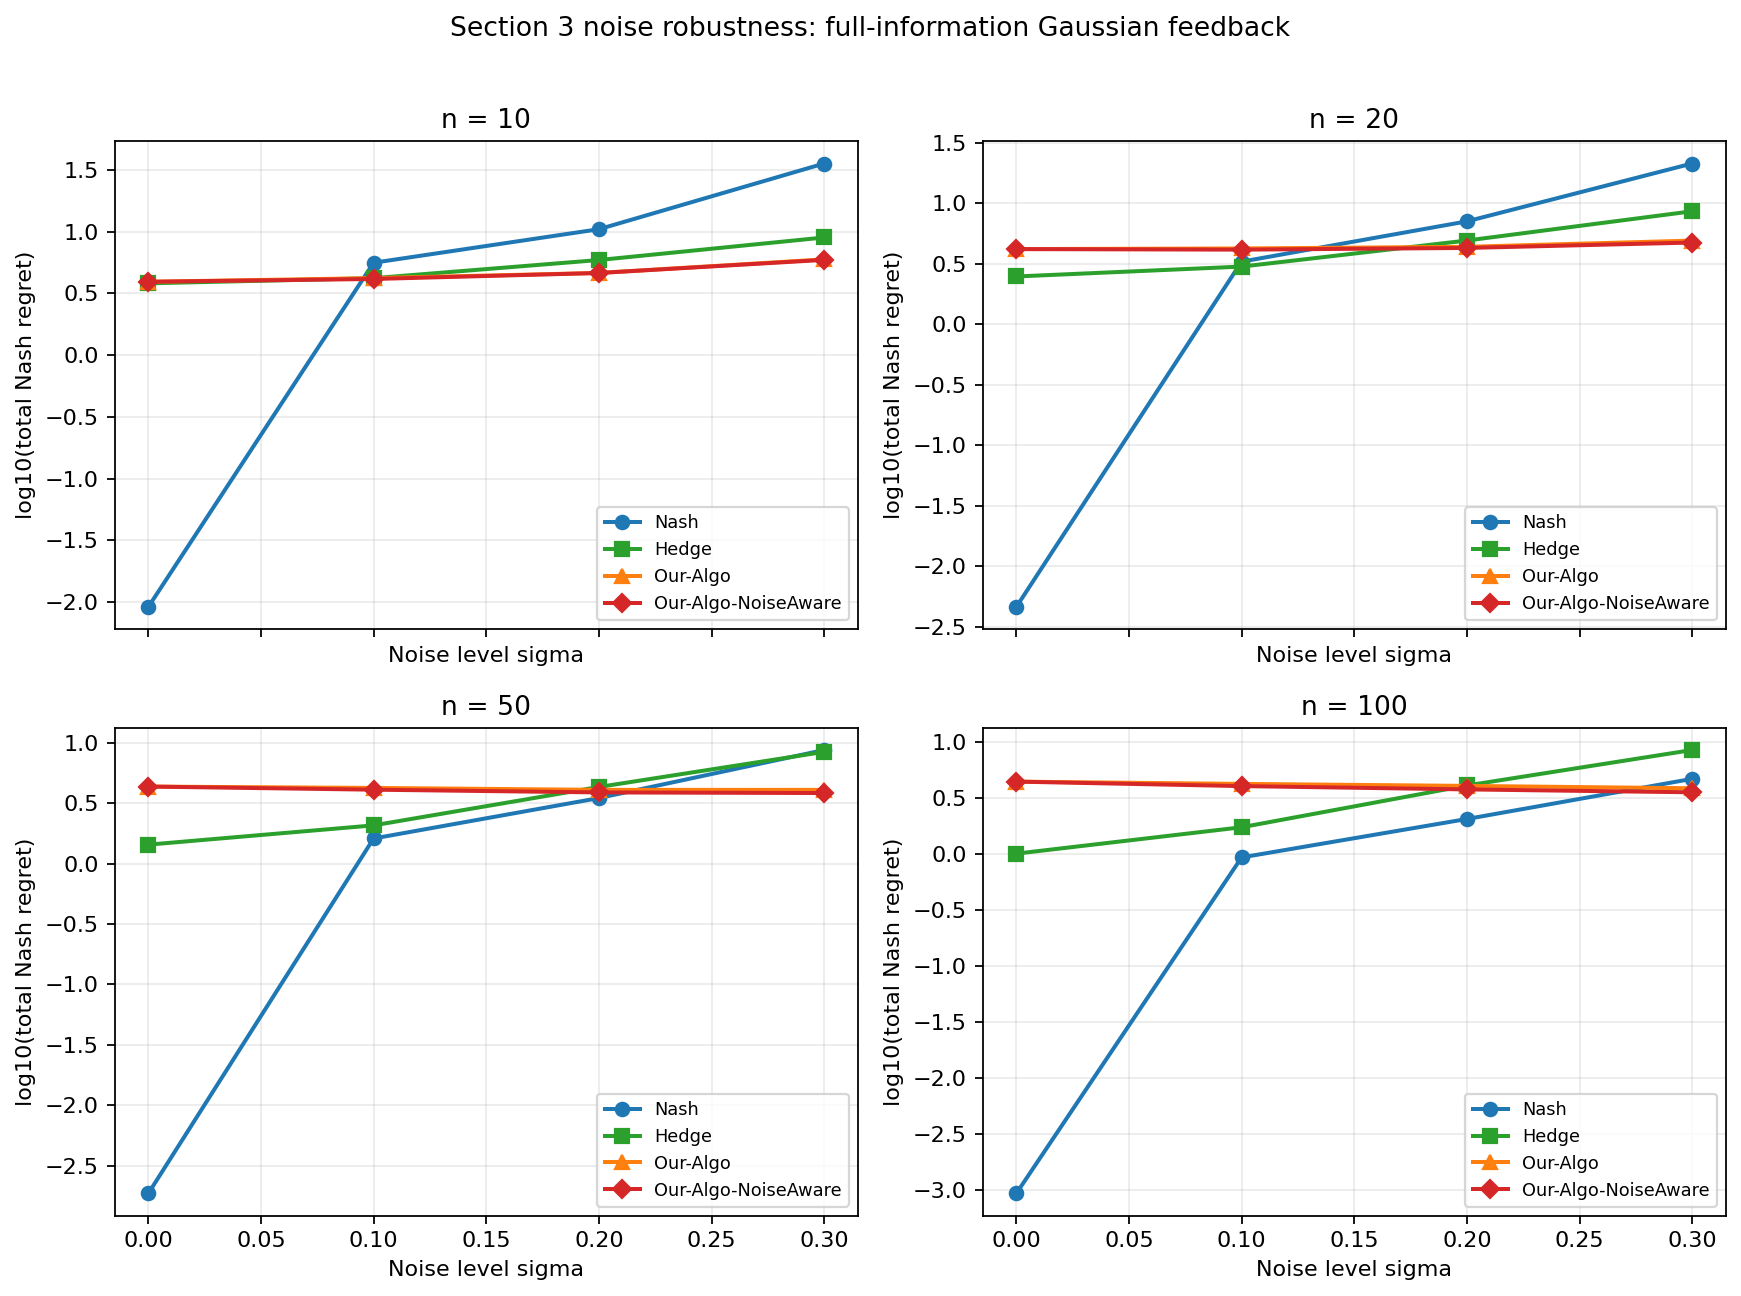

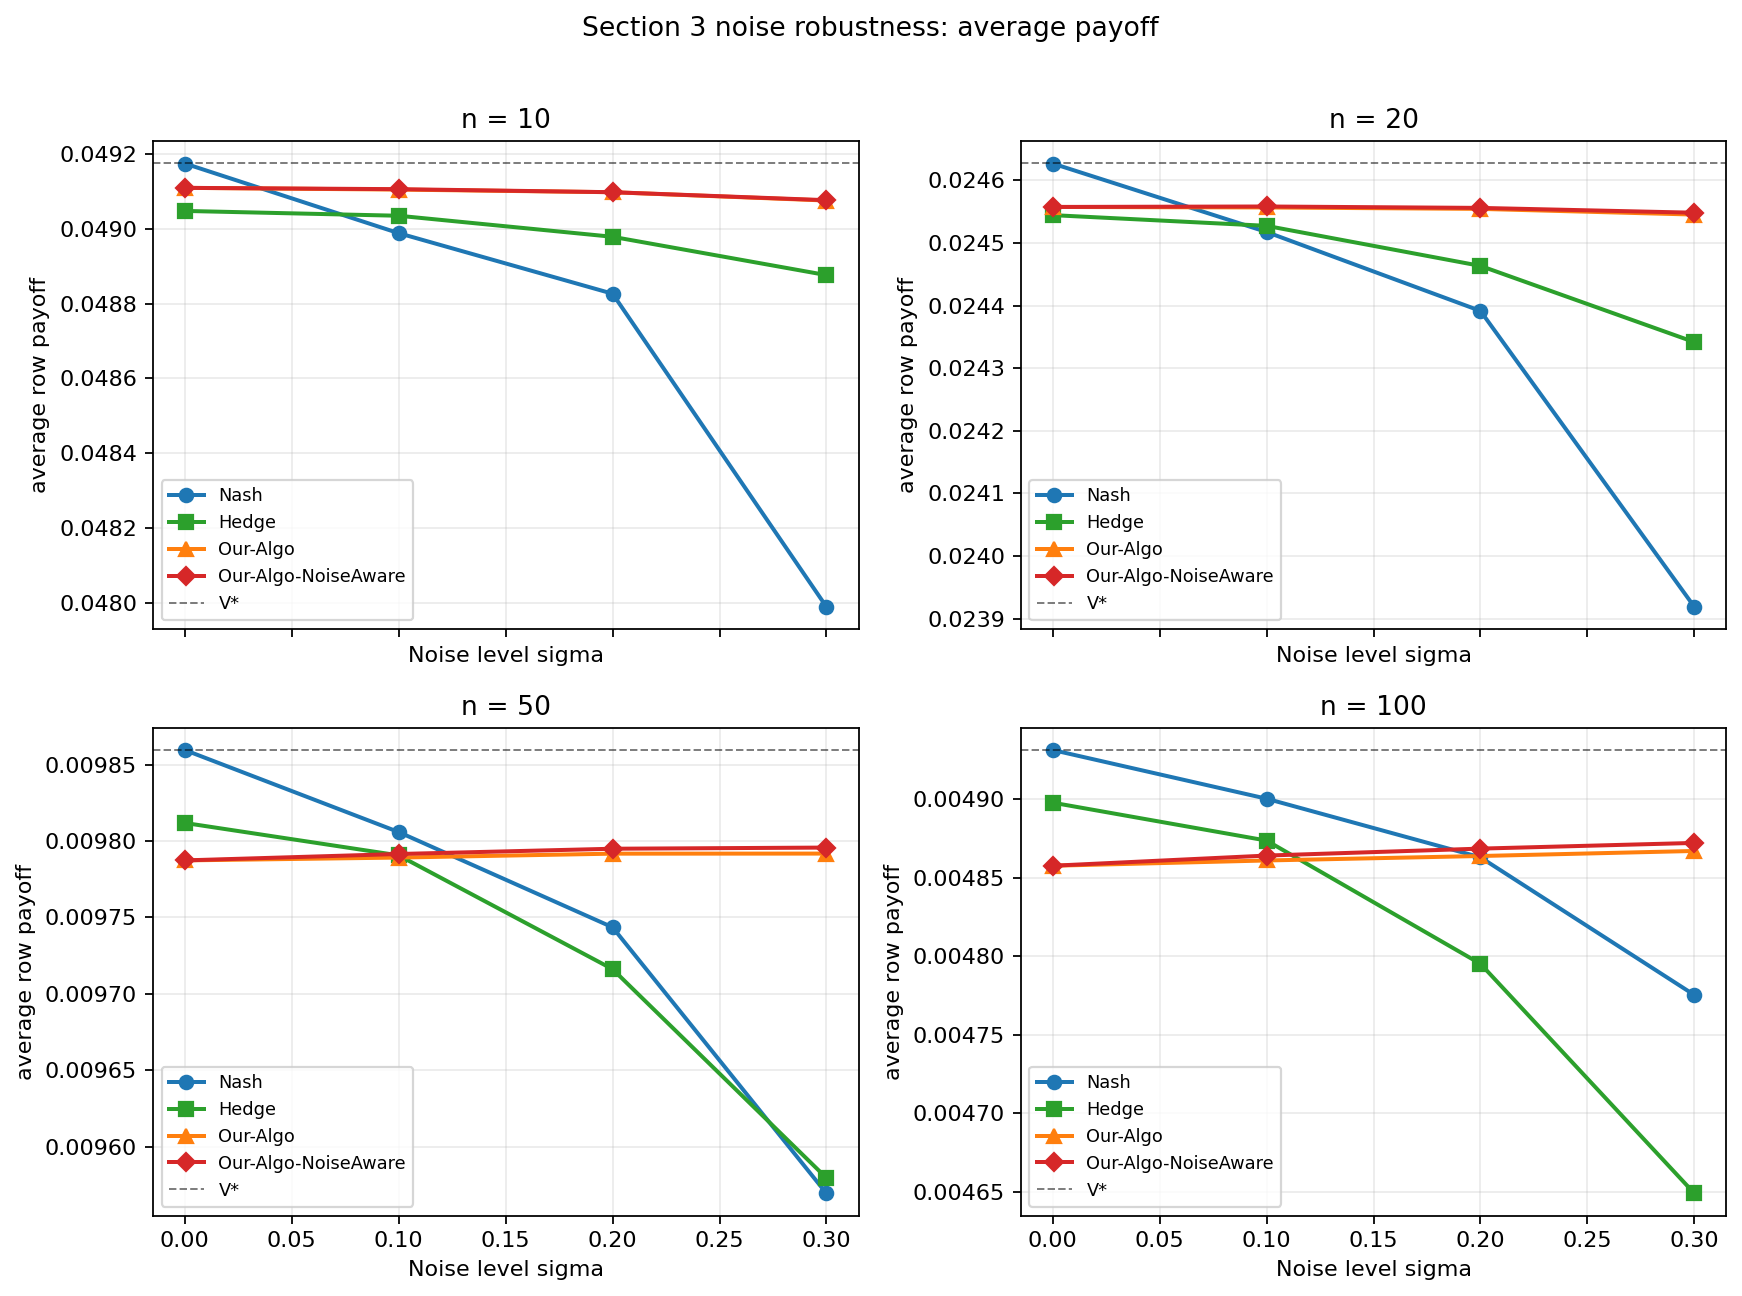

In [4]:
display(Image(filename=str(regret_path)))
display(Image(filename=str(payoff_path)))


## Convergence under high noise

The previous plots summarize final performance as `sigma` changes. The convergence plot below fixes a representative high-noise setting, `n = 20` and `sigma = 0.3`, and shows how cumulative Nash regret evolves over time. Curves are averaged over the same number of runs as the selected preset, with shaded one-standard-deviation bands.

In [5]:
convergence_bundle, convergence_path = run_convergence_and_plot(
    preset=preset,
    seed=seed,
    n=20,
    sigma=0.3,
)
convergence_metadata = convergence_bundle["metadata"]



Section 3 convergence
n=20, sigma=0.3, T=30000, n_runs=8
Nash: final R=21.26
Hedge: final R=8.57
Our-Algo: final R=4.91
Our-Algo-NoiseAware: final R=4.73
Figure saved -> D:\Users\Mateo\Personal\_Seminar_RL\Zero-Sum-MatrixGames\Extensions\Extension_Noise_Robustness_Full_info_feedback\plots\section3_convergence_medium_n20_sigma0p3.png


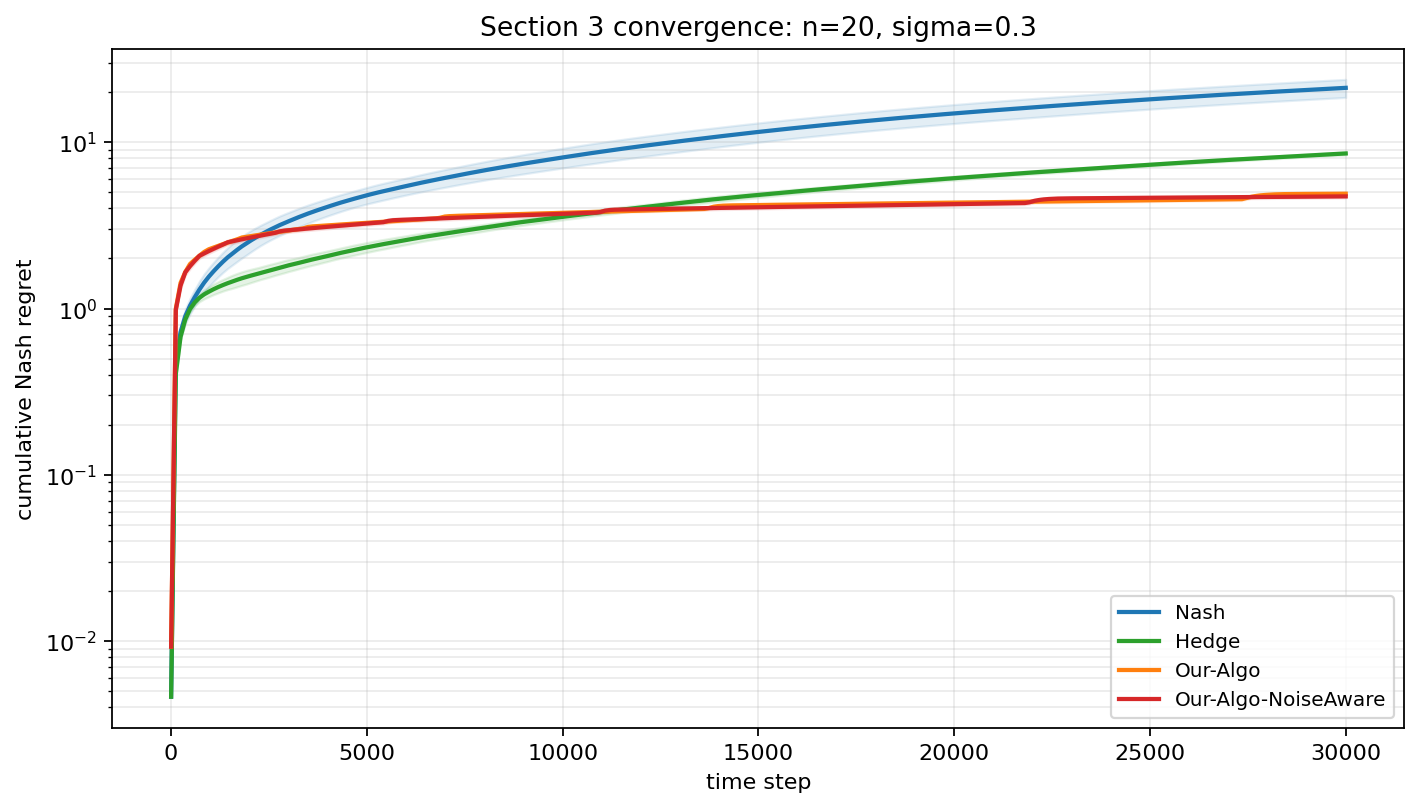

In [6]:
display(Image(filename=str(convergence_path)))


## Interpretation

Section 3 uses full-information feedback, so the learner sees much more data each round than in the bandit setting. The expected behavior is a gradual degradation as `sigma` increases, rather than a sudden collapse.

The new comparison to watch is `Our-Algo` versus `Our-Algo-NoiseAware`. If the noise-aware threshold helps, the red noise-aware curve should remain flatter in regret and/or closer to the game value in average payoff at larger `sigma`.